# **Normalization**

## **Soil**

In [ ]:
# Normalization of soil properties according to property-specific methods
# Create a copy to preserve original values
df_soil_normalized = X_train.copy()
# 
# Small constant to avoid log(0)
EPSILON = 1e-6

In [ ]:
# 1) Texture (composition): Min-Max (0-1) scaling
texture_cols = ['COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil']
for col in texture_cols:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")


COARSE_soil: Min-Max scaling applied
SAND_soil: Min-Max scaling applied
SILT_soil: Min-Max scaling applied
CLAY_soil: Min-Max scaling applied


In [ ]:
# 2) Density & pH: Robust for densities, Min-Max for pH
# Robust scaling: (x - median) / IQR
for col in ['BULK_soil', 'REF_BULK_soil']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

# Min-Max for pH
if 'PH_WATER' in df_soil_normalized.columns:
    col_min = df_soil_normalized['PH_WATER'].min()
    col_max = df_soil_normalized['PH_WATER'].max()
    if col_max > col_min:
        df_soil_normalized['PH_WATER'] = (df_soil_normalized['PH_WATER'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['PH_WATER'] = 0.0
    print("PH_WATER: Min-Max scaling applied")


BULK_soil: Robust scaling applied
REF_BULK_soil: Robust scaling applied


In [ ]:
# 3) Organic matter & nutrients
# Log + Robust for ORG_CARBON
if 'ORG_CARBON_soil' in df_soil_normalized.columns:
    # treat non-positive / sentinel values as missing before log
    oc = df_soil_normalized['ORG_CARBON_soil'].copy().astype(float)
    oc.loc[oc <= 0] = np.nan

    # log transform (safe with EPSILON)
    oc = np.log(oc + EPSILON)

    # robust scaling: (x - median) / IQR
    q1 = oc.quantile(0.25)
    q3 = oc.quantile(0.75)
    median = oc.median()
    iqr = q3 - q1
    if iqr > 0:
        oc = (oc - median) / iqr
    else:
        oc = oc - median

    # fill remaining NaNs with median of transformed values (robust fallback)
    oc = oc.fillna(oc.median())

    df_soil_normalized['ORG_CARBON_soil'] = oc
    print("ORG_CARBON: Log + Robust scaling applied")

# Log for TOTAL_N (then standard scale)
if 'TOTAL_N_soil' in df_soil_normalized.columns:
    df_soil_normalized['TOTAL_N_soil'] = np.log(df_soil_normalized['TOTAL_N_soil'] + EPSILON)
    mean_val = df_soil_normalized['TOTAL_N_soil'].mean()
    std_val = df_soil_normalized['TOTAL_N_soil'].std()
    if std_val > 0:
        df_soil_normalized['TOTAL_N_soil'] = (df_soil_normalized['TOTAL_N_soil'] - mean_val) / std_val
    else:
        df_soil_normalized['TOTAL_N_soil'] = 0.0
    print("TOTAL_N: Log + Standard scaling applied")

# Min-Max for TCARBON_EQ
if 'TCARBON_EQ_soil' in df_soil_normalized.columns:
    col_min = df_soil_normalized['TCARBON_EQ_soil'].min()
    col_max = df_soil_normalized['TCARBON_EQ_soil'].max()
    if col_max > col_min:
        df_soil_normalized['TCARBON_EQ_soil'] = (df_soil_normalized['TCARBON_EQ_soil'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['TCARBON_EQ_soil'] = 0.0
    print("TCARBON_EQ: Min-Max scaling applied")


ORG_CARBON: Log + Robust scaling applied
TOTAL_N: Log + Standard scaling applied
TCARBON_EQ: Min-Max scaling applied


In [ ]:
# 4) Cation exchange & fertility: Robust (CEC_SOIL, CEC_EFF,  TEB), Min-Max (CEC_CLAY, BSAT)
for col in ['CEC_SOIL_soil', 'CEC_EFF_soil', 'TEB_soil']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

for col in ['CEC_CLAY_soil', 'BSAT_soil']:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")

CEC_SOIL_soil: Robust scaling applied
CEC_EFF_soil: Robust scaling applied
TEB_soil: Robust scaling applied
CEC_CLAY_soil: Min-Max scaling applied
BSAT_soil: Min-Max scaling applied


In [ ]:
# 5) Salinity & saturation: Log + Robust Scaling
for col in ['ALUM_SAT_soil', 'ESP_soil', 'GYPSUM_soil', 'ELEC_COND_soil']:
    if col in df_soil_normalized.columns:
        df_soil_normalized[col] = np.log(df_soil_normalized[col] + EPSILON)
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Log + Robust scaling applied")


ALUM_SAT_soil: Log + Robust scaling applied
ESP_soil: Log + Robust scaling applied
GYPSUM_soil: Log + Robust scaling applied
ELEC_COND_soil: Log + Robust scaling applied


In [ ]:
print("\nAll normalization transformations completed")
print(f"Original shape: {df_final_merged.shape}")
print(f"Normalized shape: {df_soil_normalized.shape}")



All normalization transformations completed
Original shape: (23180, 44)
Normalized shape: (16226, 67)


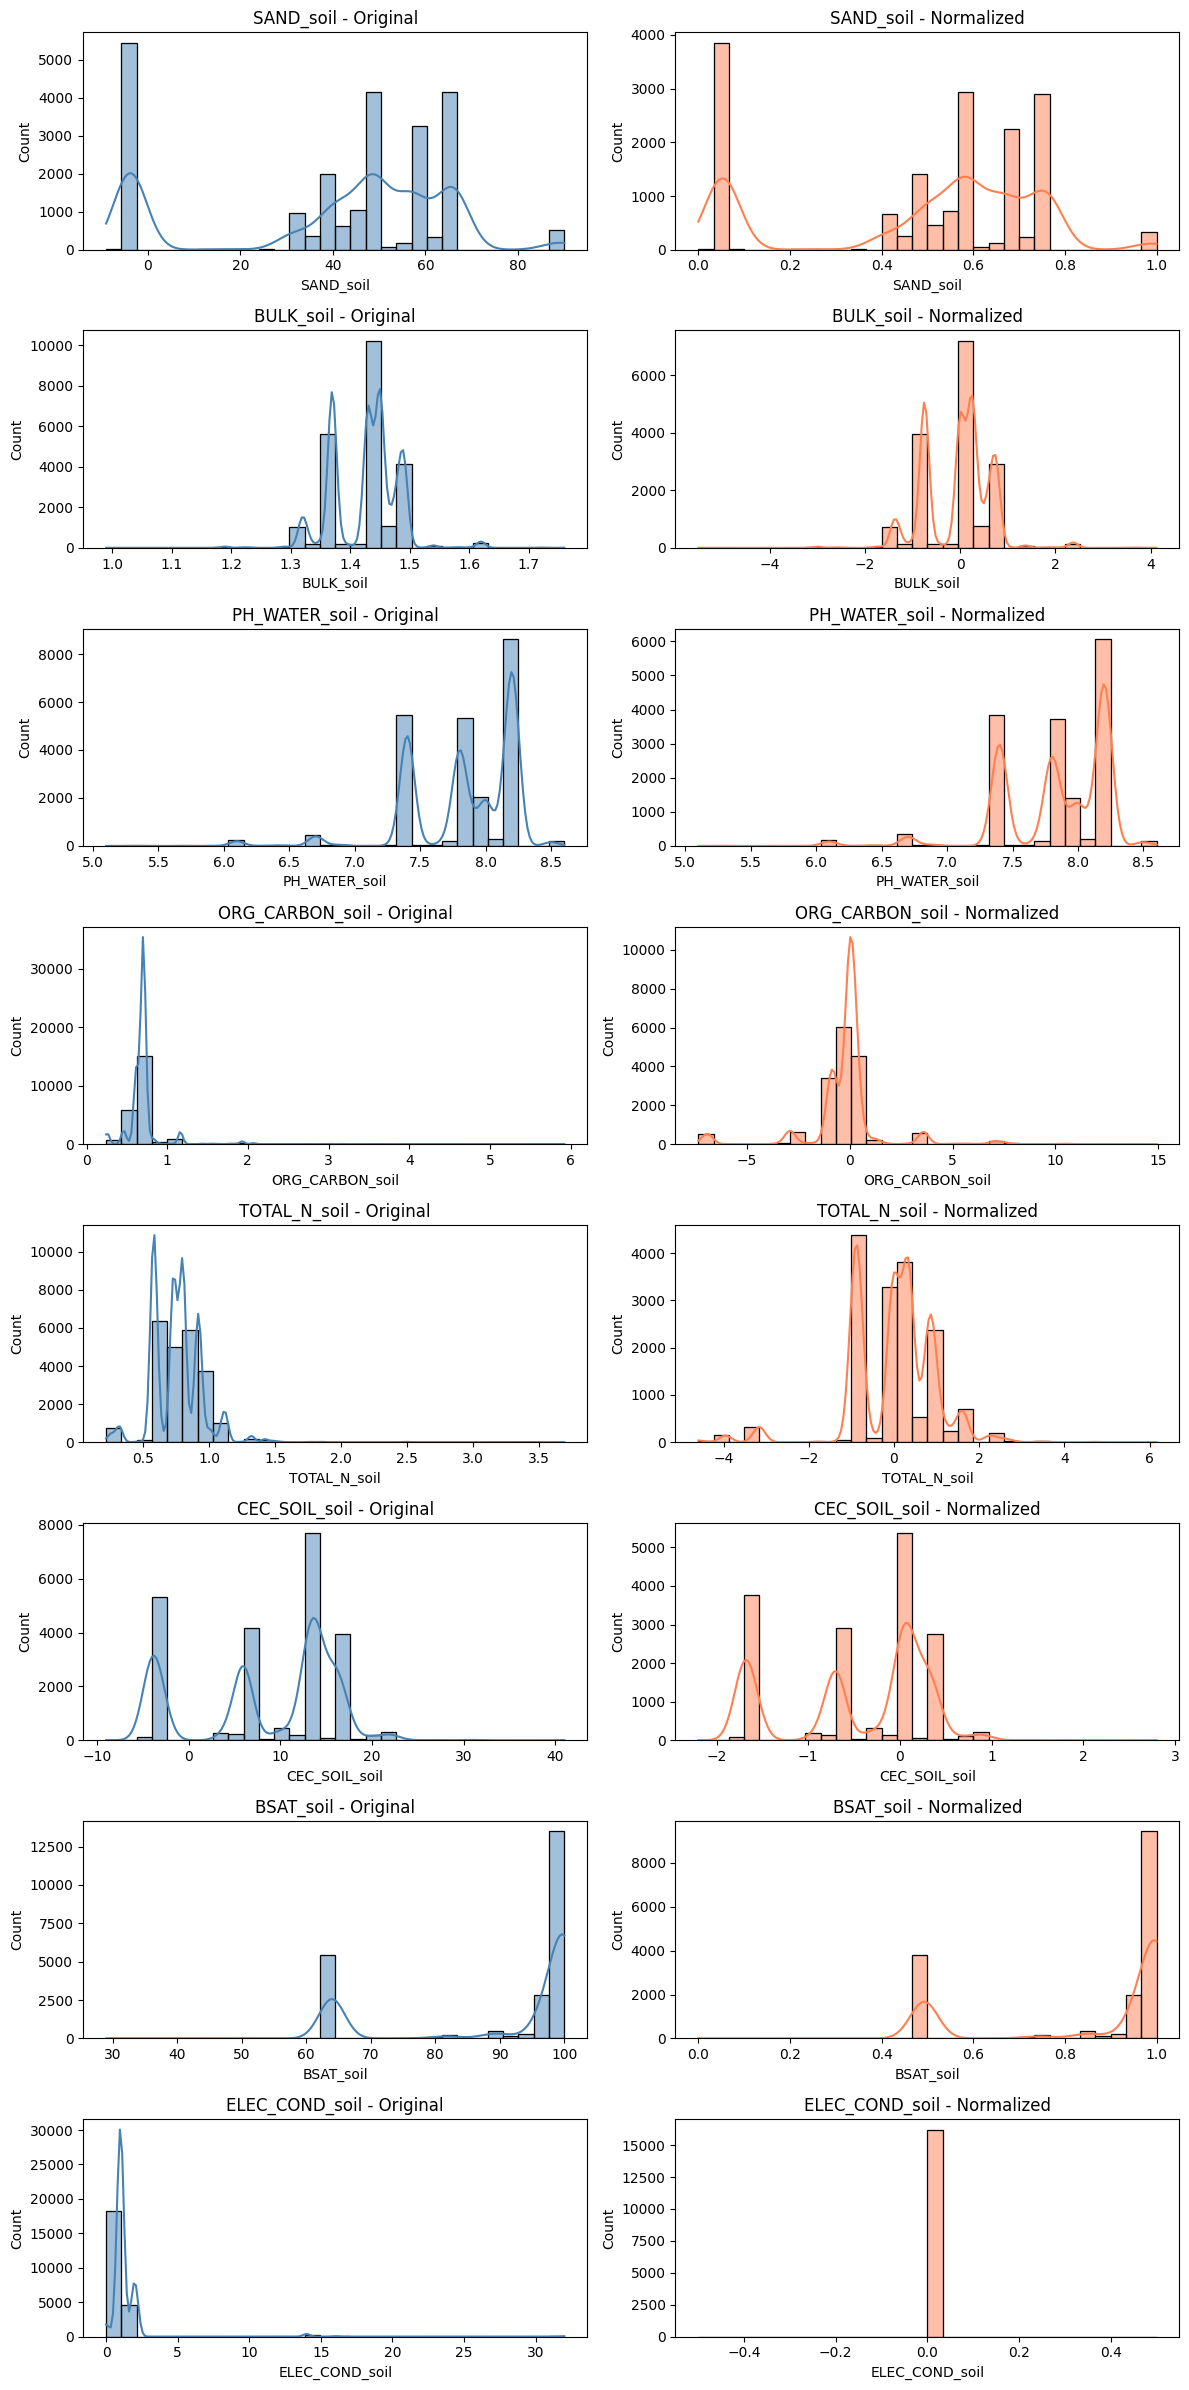

In [ ]:
# Compare distributions before and after normalization
# Select a subset of key columns to visualize
comparison_cols = ['SAND_soil', 'BULK_soil', 'PH_WATER_soil', 'ORG_CARBON_soil', 'TOTAL_N_soil', 
                   'CEC_SOIL_soil', 'BSAT_soil', 'ELEC_COND_soil']

# Filter to only columns that exist in both dataframes
comparison_cols = [c for c in comparison_cols if c in df_final_merged.columns and c in df_soil_normalized.columns]

n = len(comparison_cols)
if n > 0:
    ncols = 2  # Before and After side by side
    nrows = n
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
    
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(comparison_cols):
        # Before (original)
        ax_before = axes[i, 0]
        data_before = df_final_merged[col].dropna()
        if not data_before.empty:
            sns.histplot(data_before, bins=30, kde=True, ax=ax_before, color='steelblue')
            ax_before.set_title(f"{col} - Original")
            ax_before.set_xlabel(col)
            ax_before.set_ylabel("Count")
        else:
            ax_before.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_before.transAxes)
        
        # After (normalized)
        ax_after = axes[i, 1]
        data_after = df_soil_normalized[col].dropna()
        if not data_after.empty:
            sns.histplot(data_after, bins=30, kde=True, ax=ax_after, color='coral')
            ax_after.set_title(f"{col} - Normalized")
            ax_after.set_xlabel(col)
            ax_after.set_ylabel("Count")
        else:
            ax_after.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_after.transAxes)
    
    plt.tight_layout()
    plt.savefig('../../Rapport_TP/images/MergedPreprocess/soil_normalization_comparison.png')
    plt.show()
else:
    print("No columns available for comparison visualization")


In [ ]:
# Summary statistics: compare ranges and distributions before/after normalization
numeric_features = ['COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil', 'BULK_soil', 'REF_BULK_soil', 
                    'ORG_CARBON_soil', 'PH_WATER_soil', 'TOTAL_N_soil', 'CEC_SOIL_soil', 'CEC_CLAY_soil', 
                    'CEC_EFF_soil', 'TEB_soil', 'BSAT_soil', 'ALUM_SAT_soil', 'ESP_soil', 'TCARBON_EQ_soil', 
                    'GYPSUM_soil', 'ELEC_COND_soil']

# Filter to existing columns
numeric_features = [c for c in numeric_features if c in df_final_merged.columns and c in df_soil_normalized.columns]

summary_comparison = pd.DataFrame({
    'Original_Min': df_final_merged[numeric_features].min(),
    'Original_Max': df_final_merged[numeric_features].max(),
    'Original_Mean': df_final_merged[numeric_features].mean(),
    'Original_Std': df_final_merged[numeric_features].std(),
    'Normalized_Min': df_soil_normalized[numeric_features].min(),
    'Normalized_Max': df_soil_normalized[numeric_features].max(),
    'Normalized_Mean': df_soil_normalized[numeric_features].mean(),
    'Normalized_Std': df_soil_normalized[numeric_features].std()
})

print("Summary Statistics Comparison (Original vs Normalized)")
print("=" * 80)
display(summary_comparison.round(4))


Summary Statistics Comparison (Original vs Normalized)


,Original_Min,Original_Max,Original_Mean,Original_Std,Normalized_Min,Normalized_Max,Normalized_Mean,Normalized_Std
COARSE_soil,-9.000,46.000,7.7714,7.9554,0.0000,1.0000,0.3043,0.1448
SAND_soil,-9.000,90.000,39.7070,26.3766,0.0000,1.0000,0.4901,0.2666
SILT_soil,-9.000,46.000,21.6849,15.6058,0.0000,1.0000,0.5570,0.2845
CLAY_soil,-9.000,55.000,12.3412,10.1603,0.0000,1.0000,0.3328,0.1590
BULK_soil,0.990,1.760,1.4274,0.0543,-5.5000,4.1250,-0.0348,0.6752
REF_BULK_soil,1.200,2.030,1.6499,0.0980,-3.8333,3.0833,-0.0837,0.8148
ORG_CARBON_soil,0.242,5.923,0.6993,0.2168,-7.3756,14.9193,-0.2235,1.8180
PH_WATER_soil,5.100,8.600,7.8345,0.4157,5.1000,8.6000,7.8348,0.4174
TOTAL_N_soil,0.220,3.690,0.7571,0.1913,-4.5916,6.1647,0.0000,1.0000
CEC_SOIL_soil,-9.000,41.000,8.4999,7.8432,-2.2000,2.8000,-0.4529,0.7863


## **Climate**

In [ ]:
df_climate_normalized=df_soil_normalized.copy()
# Normalize climate features: Standard scaling (z-score)
temp_features = [c for c in df_climate_normalized.columns if c.startswith('temp_min_') or c.startswith('temp_max_') ]
scaler = StandardScaler()
df_climate_normalized[temp_features] = scaler.fit_transform(df_climate_normalized[temp_features])

In [ ]:
# log transform for precipitation
precip_features = [c for c in df_climate_normalized.columns if c.startswith('precip_') ]
for col in precip_features:
    df_climate_normalized[col] = np.log(df_climate_normalized[col] + 1e-6)

## **Elevation**

In [ ]:
#standard scaler elevation
elev_features = ['elevation']
scaler_elev = StandardScaler()
df_climate_normalized[elev_features] = scaler_elev.fit_transform(df_climate_normalized[elev_features])

In [ ]:
train_set_normalized=df_climate_normalized.copy()

## **LandCover**

no scaling or normalization needed

## **Saving X_train normalized and x_test,y_test,y_train untouched**

In [ ]:
#  saving train_set_normalized
path = "Normalized_Data_split"
if not os.path.exists(path):
    os.makedirs(path)
train_set_normalized.to_csv(os.path.join(path, 'train_set_normalized.csv'), index=False)

# rest of the split
# saving X_temp, y_train, y_temp
X_temp.to_csv(os.path.join(path, 'X_temp.csv'), index=False)
y_train.to_csv(os.path.join(path, 'y_train.csv'), index=False)
y_temp.to_csv(os.path.join(path, 'y_temp.csv'), index=False)

# X_test, X_val, y_test, 
X_test.to_csv(os.path.join(path, 'X_test.csv'), index=False)
X_val.to_csv(os.path.join(path, 'X_val.csv'), index=False)
y_test.to_csv(os.path.join(path, 'y_test.csv'), index=False)